In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import numpy as np

class Activation:
    def __init__(self, name: str):
        self.name = name

        self.functions = {
            'sigmoid': self.sigmoid,
            'tanh': np.tanh,
            'relu': self.relu,
            'linear': lambda x: x,
            'binary_step': lambda x: np.where(x >= 0, 1, 0)
        }

        self.derivatives = {
            'sigmoid': lambda out: out * (1 - out),
            'tanh': lambda out: 1 - out**2,
            'relu': self.relu_derivative,
            'linear': lambda out: np.ones_like(out),
            'binary_step': lambda out: np.zeros_like(out)
        }

        if name not in self.functions:
            raise ValueError(f"Activation '{name}' not defined")

    def forward(self, x: np.ndarray) -> np.ndarray:
        self.input = x
        self.output = self.functions[self.name](x)
        return self.output

    def derivative(self) -> np.ndarray:
        return self.derivatives[self.name](self.output)

    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        return grad_output * self.derivative()


    @staticmethod
    def sigmoid(x: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def relu(x: np.ndarray) -> np.ndarray:
        return np.maximum(0, x)

    def relu_derivative(self, out: np.ndarray) -> np.ndarray:
        return np.where(self.input > 0, 1, 0)

In [3]:
class Loss:
    def __init__(self, name: str):
        self.name = name

        self.functions = {
            'mse': lambda y_true, y_pred: np.mean((y_true - y_pred)**2),
            'cross_entropy': self.cross_entropy
        }

        self.derivatives = {
            'mse': lambda y_true, y_pred: 2 * (y_pred - y_true) / y_true.shape[0],
            'cross_entropy': self.cross_entropy_derivative
        }

        if name not in self.functions:
            raise ValueError(f"Loss '{name}' don't define.")

    def forward(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        return self.functions[self.name](y_true, y_pred)

    def derivative(self, y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
        return self.derivatives[self.name](y_true, y_pred)

    @staticmethod
    def cross_entropy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    @staticmethod
    def cross_entropy_derivative(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return (y_pred - y_true) / (y_true.shape[0] * y_pred * (1 - y_pred))


In [9]:
class ActivationLayer:
    def __init__(self, activation: str):
        self.activation = Activation(activation)
        self.output = None
        self.input = None


    def forward(self, inputs: np.ndarray) -> np.ndarray:
        self.input = inputs
        self.output = self.activation.forward(inputs)
        return self.output

    def backward(self, output_error: np.ndarray, learning_rate: float = None) -> np.ndarray:
        return output_error * self.activation.derivative()

In [5]:
class Layer:

    def __init__(self, num_neurons, num_inputs):
        self.num_neurons = num_neurons
        self.num_inputs = num_inputs

        self.weights = np.random.uniform(-1,1,(num_neurons, num_inputs))
        self.bias = np.random.uniform(-1,1,(1,num_neurons))

        self.input = None
        self.output = None

    def forward(self, inputs: np.ndarray) -> np.ndarray:
        inputs = np.atleast_2d(inputs)  # fuerza 2D
        self.input = inputs
        self.output = inputs @ self.weights.T + self.bias
        return self.output

    def backward(self, output_error: np.ndarray, learning_rate: float) -> np.ndarray:
        weight_gradient = output_error.T @ self.input / self.input.shape[0]
        bias_gradient = output_error.mean(axis=0, keepdims=True)

        self.weights -= learning_rate * weight_gradient
        self.bias -= learning_rate * bias_gradient

        return output_error @ self.weights

In [6]:
class MLP:
    def __init__(self, layers: list, loss_name: str = "mse"):
        self.layers: list= layers
        self.loss = Loss(loss_name)

    def forward(self, inputs: np.ndarray) -> np.ndarray:
        output = inputs

        for layer in self.layers:
            output = layer.forward(output)
        return output

    def backward(self, inputs: np.ndarray, targets: np.ndarray, learning_rate: float) -> float:
        predictions = self.forward(inputs)
        error_gradient = self.loss.derivative(targets, predictions)

        for layer in reversed(self.layers):
          error_gradient = layer.backward(error_gradient, learning_rate)

        return self.loss.forward(targets, predictions)

    def train(self,inputs: np.ndarray,targets: np.ndarray,learning_rate: float = 0.01,epochs: int = 100,debug: bool = False) -> list[float]:
        loss_history = [] if debug else None

        for epoch in range(epochs):
            loss_value = self.backward(inputs, targets, learning_rate)
            if debug:
                loss_history.append(loss_value)
            if epoch % 10 == 0:
                print(f"Epoch {epoch}, Loss: {loss_value}")

        return loss_history


In [7]:
def plot_loss(loss_history, title):
    plt.figure(figsize=(6,4))
    plt.plot(loss_history)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.grid(True)
    plt.show()

def show_predictions(model, inputs, name):
    print(f"\n{name} predictions")

    for x in inputs:
        prediction = model.forward(np.array([x]))
        print(f"{x} -> {np.round(prediction)}")

def check_accuracy(model, inputs, targets):
    correct = 0

    for x, y in zip(inputs, targets):
        prediction = np.round(model.forward(np.array([x])))
        if (prediction == y).all():
            correct += 1

    accuracy = correct / len(inputs)

    print(f"Accuracy: {accuracy:.2f}")

    return accuracy

Epoch 0, Loss: 0.7813108653620316
Epoch 10, Loss: 0.23676126804734976
Epoch 20, Loss: 0.13270756603736295
Epoch 30, Loss: 0.09181694110876457
Epoch 40, Loss: 0.0750577029816705
Epoch 50, Loss: 0.06797239188203169
Epoch 60, Loss: 0.06491169102026711
Epoch 70, Loss: 0.06357047096615778
Epoch 80, Loss: 0.06297728742041757
Epoch 90, Loss: 0.06271340227106767


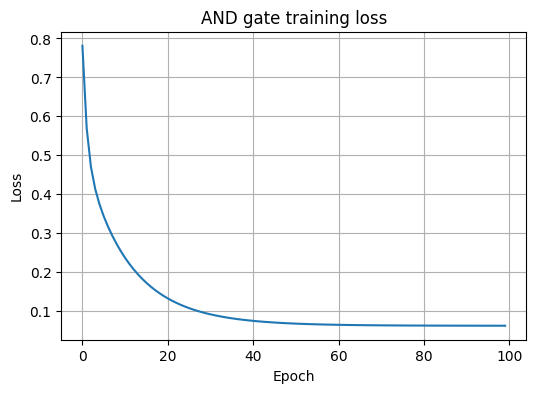


AND gate predictions
[0 0] -> [[-0.]]
[0 1] -> [[0.]]
[1 0] -> [[0.]]
[1 1] -> [[1.]]
Accuracy: 1.00


In [10]:
and_inputs = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

and_targets = np.array([
    [0],
    [0],
    [0],
    [1]
])

and_layers = [
    Layer(num_neurons=1, num_inputs=2),
    ActivationLayer("linear")
]

and_mlp = MLP(and_layers)
and_loss = and_mlp.train(and_inputs, and_targets, learning_rate=0.5, epochs=100, debug=True)

plot_loss(and_loss, "AND gate training loss")
show_predictions(and_mlp, and_inputs, "AND gate")
and_accuracy = check_accuracy(and_mlp, and_inputs, and_targets)

Epoch 0, Loss: 1.232733925215829
Epoch 10, Loss: 0.07105199913561093
Epoch 20, Loss: 0.06429734778782252
Epoch 30, Loss: 0.063640046781317
Epoch 40, Loss: 0.06324849967103753
Epoch 50, Loss: 0.06299967967718073
Epoch 60, Loss: 0.06283829009279203
Epoch 70, Loss: 0.06273169780683656
Epoch 80, Loss: 0.06266018314652456
Epoch 90, Loss: 0.06261156498528356


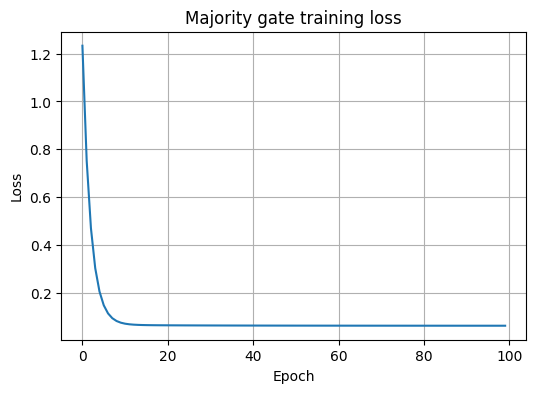


Majority gate predictions
[0 0 0] -> [[-0.]]
[0 0 1] -> [[0.]]
[0 1 0] -> [[0.]]
[0 1 1] -> [[1.]]
[1 0 0] -> [[0.]]
[1 0 1] -> [[1.]]
[1 1 0] -> [[1.]]
[1 1 1] -> [[1.]]
Accuracy: 1.00
Majority gate accuracy: 100.00%


In [11]:
majority_inputs = np.array([
    [0,0,0],
    [0,0,1],
    [0,1,0],
    [0,1,1],
    [1,0,0],
    [1,0,1],
    [1,1,0],
    [1,1,1]
])

majority_targets = np.array([
    [0],
    [0],
    [0],
    [1],
    [0],
    [1],
    [1],
    [1]
])
majority_layers = [
    Layer(num_neurons=1, num_inputs=3),
    ActivationLayer("linear")
]

majority_mlp = MLP(majority_layers)
majority_loss = majority_mlp.train(majority_inputs,majority_targets,learning_rate=0.5,epochs=100,debug=True)


plot_loss(majority_loss, "Majority gate training loss")
show_predictions(majority_mlp, majority_inputs, "Majority gate")

majority_accuracy = check_accuracy(majority_mlp, majority_inputs, majority_targets)
print(f"Majority gate accuracy: {majority_accuracy*100:.2f}%")

Epoch 0, Loss: 0.2628565174759321
Epoch 10, Loss: 0.25960678922657576
Epoch 20, Loss: 0.257138686658821
Epoch 30, Loss: 0.2552886556135899
Epoch 40, Loss: 0.2539157506188292
Epoch 50, Loss: 0.2529045127591542
Epoch 60, Loss: 0.25216369016414253
Epoch 70, Loss: 0.2516229938751316
Epoch 80, Loss: 0.2512292804935372
Epoch 90, Loss: 0.2509429101831852
Epoch 100, Loss: 0.2507346062337644
Epoch 110, Loss: 0.2505829016831115
Epoch 120, Loss: 0.25047213937768326
Epoch 130, Loss: 0.25039094413301466
Epoch 140, Loss: 0.250331075457609
Epoch 150, Loss: 0.25028657640631924
Epoch 160, Loss: 0.2502531475533496
Epoch 170, Loss: 0.2502276893987003
Epoch 180, Loss: 0.2502079693999981
Epoch 190, Loss: 0.25019238048861536
Epoch 200, Loss: 0.25017976636056494
Epoch 210, Loss: 0.2501692953053028
Epoch 220, Loss: 0.2501603692095021
Epoch 230, Loss: 0.25015255799494596
Epoch 240, Loss: 0.2501455524167751
Epoch 250, Loss: 0.2501391300993647
Epoch 260, Loss: 0.250133131107613
Epoch 270, Loss: 0.250127440382091

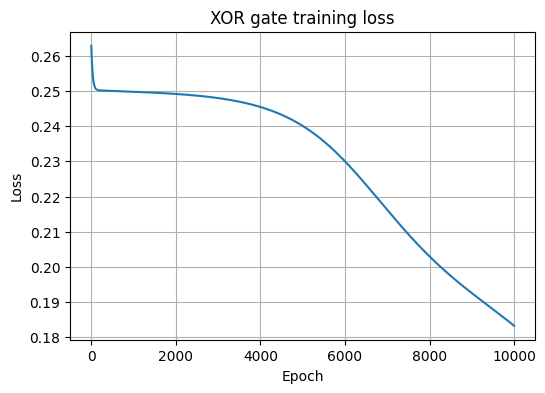


XOR gate predictions
[0 0] -> [[0.]]
[0 1] -> [[0.]]
[1 0] -> [[1.]]
[1 1] -> [[0.]]
Accuracy: 0.75
XOR gate accuracy: 75.00%


In [12]:

xor_inputs = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

xor_targets = np.array([
    [0],
    [1],
    [1],
    [0]
])

xor_layers = [
    Layer(num_neurons=2, num_inputs=2),
    ActivationLayer("sigmoid"),
    Layer(num_neurons=1, num_inputs=2),
    ActivationLayer("sigmoid")
]

xor_mlp = MLP(xor_layers)


xor_loss = xor_mlp.train(xor_inputs,xor_targets,learning_rate=0.3,epochs=10000, debug=True)

plot_loss(xor_loss, "XOR gate training loss")
show_predictions(xor_mlp, xor_inputs, "XOR gate")

xor_accuracy = check_accuracy(xor_mlp, xor_inputs, xor_targets)
print(f"XOR gate accuracy: {xor_accuracy*100:.2f}%")